In [1]:
import sys
import os

sys.path.append('/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit')
sys.path.append('/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron')
sys.path.append('/home/paule/open_mc_projects/MC-1D_DT')



from src.geometry_classes import Geometry, Material, Neutron, Source, _BatchSource
import src.geometry_classes as geom
import src.performance_classes as perf
import src.tally_classes as tally
import src.vectfit as vf
import src.export_simulation_v3 as xpcsv
import src.export_print_csv as xpcsv
import src.reconr as reconr

import openmc

openmc.config['cross_sections'] = "/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/cross_sections.xml"


data_folder = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/wmp'
file_h5_test = '092235.h5'
multipole_data = openmc.data.WindowedMultipole.from_hdf5(os.path.join(data_folder, file_h5_test))


nuclide_name = [ "U238", "U235", "Pu239","Pu240", "Cnat", "O16", "H1", "Fe56", "Xe135", "Na23" ]
nuclide_list = [ '092238', '092235', '094239', '094240', '006000',  '008016', '001001','026056','054135', '011023']
nuclides = {}

for nuclide_id, name in zip(nuclide_list, nuclide_name):
    file_h5 = nuclide_id + '.h5'
    nuclides[name] = openmc.data.WindowedMultipole.from_hdf5(
        os.path.join(data_folder, file_h5)
    )


['/home/paule/anaconda3/envs/vectfit39/lib/python39.zip', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/lib-dynload', '', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit', '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron', '/home/paule/open_mc_projects/MC-1D_DT', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit']


In [2]:
# One slab of U238 — simple test case
U238 = nuclides['U238']
U235 = nuclides['U235']

# ============================================================================
# Uranium atom density
# ============================================================================
# Uranium metal density ~ 19.1 g/cm³,
# N = rho * Na / A  (atoms/cm³)
rho_U   = 19.1               # g/cm³
NA      = 6.02214076e23      # atoms/mol

x_U235 = 0.00                # 0% enrichment
x_U238 = 1.0 - x_U235

M_U8   = 238.05078826        # g/mol
M_U5   = 235.0439299         # g/mol
N_total_U8 = rho_U * NA / (x_U238 * M_U8 + x_U235 * M_U5)
N_total_U5 = rho_U * NA / (x_U235 * M_U5 + x_U238 * M_U8)

N_U235 = 1.0 * N_total_U5   # 0%  enrichment
N_U238 = 1.0 * N_total_U8   # 100%

slab1 = Material(
    name     = "cell 1",
    nuclides = [('U238', N_U238)],
    T        = 293.6,    # K (~20 °C)
)

slab2 = Material(
    name     = "cell 2",
    nuclides = [('U238', N_U238)],
    T        = 2000,     # K
)


('U238', 4.831863374901811e+22)
('U238', 4.831863374901811e+22)


In [3]:
print(slab1._xs_evaluation(10))

[4.60978047e-01 2.15295122e-02 3.79008897e-08]


In [6]:



# ============================================================================
# Geometry  (two slabs)
# ============================================================================
geom = Geometry(majorant_log=True, verbose=False)
geom.xs_dir = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/wmp'

geom.add_material(slab1)
geom.add_material(slab2)
geom.boundaries     = [0.0, 2.0, 15.0]  # cm
geom.material_array = [slab1, slab2]

# Flux tally: 5 energy groups
energy_bins = [10.0, 50.0, 600.0, 1e4, 1e6, 2e7]  # eV
geom.attach_flux_tally(energy_bins)

# Verification tally: same energy bins, surface at slab1/slab2 interface
geom.attach_verification_tally(
    energy_bins = energy_bins,
    surface_xs  = [2.0],        # slab1/slab2 interface
)

# Majorant and XS method
geom.maj_mat_method = "simple"  # majorant method: "maj_mat" 
geom.set_maj_xs_method(method="vectfit", xs_maj_file_dir='src/vectfit_data')  # majorant XS method: "vectfit" 
geom.set_access_method("reconr", last_energy= 600, err_lim=0.0001, err_max=0.001)  # access method: "reconr" or "simple"
geom.set_mode("analysis", filename='validation/xs_generation/statepoint.200.h5')


# ============================================================================
# Source  (monoenergetic, at x=0, pointing right)
# ============================================================================
N_NEUTRONS  = 10000   # neutrons per batch
N_BATCHES   = 5    # number of independent batches (100 neutrons each)

src = Source(
    neutron_nbr  = N_NEUTRONS,
    energy_range = [500, 150],
    energy_dist  = "mono",
    position     = [0.0, 0.0, 0.0],
    direction    = [1.0, 0.0, 0.0],
)




U238
U238
15.0
Building majorant XS grid for RECONR access method with settings:
xs_methodod: vectfit
maj_mat_method: simple
materials: ['cell 1', 'cell 2']
4309
600
 Evaluating the majorant cross section with RECONR stacking algorithm
err_lim = 0.0001, err_max = 0.001, err_int = 5e-09
last energy to add = 599.5985648781146 eV
number of windows = 4309
done


[1e-05, 1.0627298288656516e-05, 1.1254596577313033e-05, 1.188189486596955e-05, 1.2509193154626067e-05, 1.3136491443282584e-05, 1.3763789731939102e-05, 1.5018386309252136e-05, 1.627298288656517e-05, 1.7527579463878204e-05, 1.8782176041191238e-05, 2.0036772618504272e-05, 2.1291369195817306e-05, 2.254596577313034e-05, 2.3800562350443375e-05, 2.505515892775641e-05, 2.6309755505069443e-05, 2.7564352082382477e-05, 2.881894865969551e-05, 3.0073545237008542e-05, 3.132814181432157e-05, 3.258273839163461e-05, 3.5091931546260675e-05, 3.7601124700886744e-05, 4.011031785551281e-05, 4.261951101013888e-05, 4.512870416476495e-05, 4.763789731939102e-05, 5.0147090474017085e-05, 5.265628362864315e-05, 5.5165476783269215e-05, 5.767466993789528e-05, 6.018386309252135e-05, 6.269305624714742e-05, 6.520224940177349e-05, 6.771144255639956e-05, 7.022063571102562e-05, 7.523902202027776e-05, 8.02574083295299e-05, 8.527579463878203e-05, 9.029418094803417e-05, 9.53125672572863e-05, 0.00010033095356653843, 0.0001053

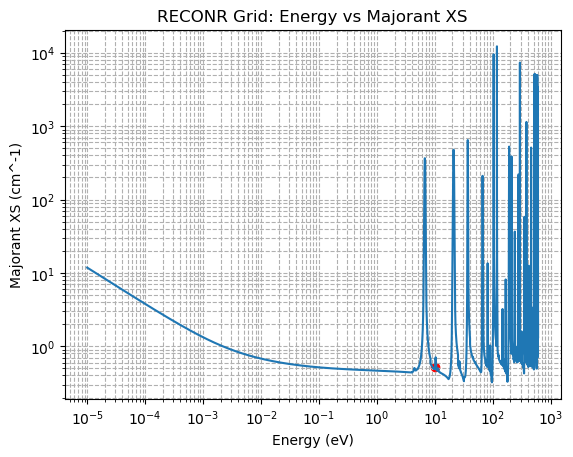

In [7]:
print(geom.reconr_e_grid)
print(len(geom.reconr_e_grid))
# plot reconr grid (first column is energy, second column is majorant xs)
import matplotlib.pyplot as plt
plt.plot(geom.reconr_e_grid, geom.reconr_maj_xs_grid)
plt.scatter(10, geom.access_majorant_xs(10), color='red', label='Accessed Majorant XS at 10 eV')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (eV)')
plt.ylabel('Majorant XS (cm^-1)')
plt.title('RECONR Grid: Energy vs Majorant XS')
plt.grid(True, which="both", ls="--")
plt.show()



In [ ]:
batch_stats = geom.run_source(src)
print(f"mode: {geom.mode}")
print(f"majorant XS method: {geom.maj_xs_method}")
print(f"majorant material method: {geom.maj_mat_method}")
print(f"access method: {geom.access_method}")
print(geom.summary())

##To do tmr :
# check that all the methods are converging toward the same results --> present to Ben in possible


Running source with following setttings:
  Mode: analysis
  Majorant XS method: vectfit
  Material majorant method: simple
  Access method: reconr
mode: analysis
majorant XS method: vectfit
majorant material method: simple
access method: reconr
  SIMULATION SUMMARY
  Neutrons simulated      :     10,000
  Absorbed fraction       :    47.480%
  Leaked fraction         :    52.520%
------------------------------------------------------------
  Mean scatters/neutron   :       7.17
  Mean virtual/neutron    :       2.83
  Mean path length  [cm]  :    13.2194
------------------------------------------------------------
  MAJORANT XS DIAGNOSTICS
  Majorant updates        :     81,723
  Mean majorant [cm⁻¹]    :     1.0915
  Max  majorant [cm⁻¹]    :   955.8593
  Mean margin (maj/real)  :      1.330
  Min margin (maj/real)  :      1.000
  Max margin (maj/real)  :    629.112
  Most-limiting material  : cell 2
  FLUX TALLY (track-length estimator)
    Energy groups : (5,)
    Histories     : 10

In [5]:

xpcsv.export_cross_batch_stats(batch_stats, geom, print_to_console=True)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
print(slab1.nuclides)
print(slab1.total_density)

[(<openmc.data.multipole.WindowedMultipole object at 0x7d3514a68220>, 4.831863374901811e+22)]
4.831863374901811e+22


In [ ]:

# ============================================================================
# Materials
# ============================================================================
slab1 = Material(
    name     = "cell 1",
    nuclides = [('U238', N_U238)],
    T        = 293.6,    # K (~20 °C)
)

slab2 = Material(
    name     = "cell 2",
    nuclides = [('U238', N_U238)],
    T        = 2000,     # K
)

# ============================================================================
# Geometry  (two slabs)
# ============================================================================
geom = Geometry(majorant_log=True, verbose=False)
geom.xs_dir = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/wmp'

geom.add_material(slab1)
geom.add_material(slab2)
geom.boundaries     = [0.0, 2.0, 15.0]  # cm
geom.material_array = [slab1, slab2]

# Flux tally: 5 energy groups
energy_bins = [10.0, 50.0, 600.0, 1e4, 1e6, 2e7]  # eV
geom.attach_flux_tally(energy_bins)

# Verification tally: same energy bins, surface at slab1/slab2 interface
geom.attach_verification_tally(
    energy_bins = energy_bins,
    surface_xs  = [2.0],        # slab1/slab2 interface
)

# Majorant and XS method
geom.set_mode("validation", filename='validation/xs_generation/statepoint.200.h5')
#geom.df_group_xs = df_cross_section

# ============================================================================
# Source  (monoenergetic, at x=0, pointing right)
# ============================================================================
N_NEUTRONS  = 100   # neutrons per batch
N_BATCHES   = 5    # number of independent batches (100 neutrons each)

src = Source(
    neutron_nbr  = N_NEUTRONS,
    energy_range = [500, 150],
    energy_dist  = "mono",
    position     = [0.0, 0.0, 0.0],
    direction    = [1.0, 0.0, 0.0],
)

print(geom.reconr_grid)



('U238', 4.831863374901811e+22)
('U238', 4.831863374901811e+22)
U238
U238
15.0
  Batch   1/5  (100 neutrons)  wall=1.036s
  Batch   2/5  (100 neutrons)  wall=1.142s
  Batch   3/5  (100 neutrons)  wall=0.976s
  Batch   4/5  (100 neutrons)  wall=1.003s
  Batch   5/5  (100 neutrons)  wall=0.991s

  CROSS-BATCH STATISTICS

  FLUX TALLY [cm · src-n⁻¹]
  Group                               Mean           ±Std    Rel.Err
  -----------------------------------------------------------------
  10-50 eV                      0.0000e+00     0.0000e+00        inf
  50-600 eV                     1.4127e+01     4.0099e-01     0.0284
  600-10000 eV                  0.0000e+00     0.0000e+00        inf
  10000-1000000 eV              0.0000e+00     0.0000e+00        inf
  1000000-20000000 eV           0.0000e+00     0.0000e+00        inf

  ABSORPTION RATE [reactions · src-n⁻¹]
  Region / Group                      Mean           ±Std    Rel.Err
  ---------------------------------------------------------

In [ ]:
# ============================================================================
# Run — batch mode
# ============================================================================
batch_stats = geom.run_batch(src, N_BATCHES)
xpcsv.export_cross_batch_stats(batch_stats, geom, print_to_console=True)
# ============================================================================
# Results
# ============================================================================
#print(geom.summary())


print(geom._nuclides_wmp_lib)
print(geom.nuclides)

{'U238': <openmc.data.multipole.WindowedMultipole object at 0x71305502adf0>}
{'U238': (<openmc.data.multipole.WindowedMultipole object at 0x71305502adf0>, 4.831863374901811e+22)}
